In [ ]:
# ==========================================
# STEP 1: Import Required Libraries
# ==========================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek
!pip install category_encoders --quiet
from category_encoders import TargetEncoder

# ==========================================
# STEP 2: Load Dataset
# ==========================================
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("UCI_Credit_Card.csv")
print("✅ Dataset loaded successfully! Shape:", df.shape)

# ==========================================
# STEP 3: Basic Cleaning
# ==========================================
# Drop duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# ==========================================
# STEP 4: Softer Outlier Removal
# ==========================================
num_cols = [
    'LIMIT_BAL','AGE','BILL_AMT1','BILL_AMT2','BILL_AMT3',
    'BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'
]

for col in num_cols:
    Q1 = df[col].quantile(0.05)
    Q3 = df[col].quantile(0.95)
    df = df[(df[col] >= Q1) & (df[col] <= Q3)]

print("✅ Cleaning Complete. Shape:", df.shape)

# ==========================================
# STEP 5: Feature Engineering
# ==========================================
# Ensure target column name consistency
target_col = 'default.payment.next.month'

# Binary encoding for categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    if df[col].nunique() == 2:
        df[col] = le.fit_transform(df[col])

# Target Encoding for multi-category columns
multi_cat_cols = [col for col in df.select_dtypes(include=['object']).columns if df[col].nunique() > 2]
if multi_cat_cols:
    te = TargetEncoder(cols=multi_cat_cols)
    df[multi_cat_cols] = te.fit_transform(df[multi_cat_cols], df[target_col])

print("✅ Feature Engineering Complete")

# ==========================================
# STEP 6: Split Features and Target
# ==========================================
X = df.drop(columns=[target_col])
y = df[target_col]

print("\nBefore Resampling:\n", y.value_counts())

# ==========================================
# STEP 7: Handle Class Imbalance (SMOTE + Tomek)
# ==========================================
if len(y.unique()) > 1:
    smt = SMOTETomek(random_state=42)
    X_res, y_res = smt.fit_resample(X, y)
    print("\n✅ After Resampling:\n", y_res.value_counts())
else:
    print("\n⚠️ SMOTE not applied — target has only one class!")

# ==========================================
# STEP 8: Normalize Data
# ==========================================
scaler = StandardScaler()

if len(y.unique()) > 1:
    X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\n✅ Normalization Done")
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# ==========================================
# STEP 9: Final Verification
# ==========================================
print("\n✅ Preprocessing Pipeline Completed Successfully!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.3 MB/s eta 0:00:00


Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv
✅ Dataset loaded successfully! Shape: (30000, 25)
✅ Cleaning Complete. Shape: (13241, 25)
✅ Feature Engineering Complete

Before Resampling:
 default.payment.next.month
0    9704
1    3537
Name: count, dtype: int64


/tmp/ipython-input-2833165386.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)



✅ After Resampling:
 default.payment.next.month
1    9293
0    9293
Name: count, dtype: int64

✅ Normalization Done
Train Shape: (14868, 24)
Test Shape: (3718, 24)

✅ Preprocessing Pipeline Completed Successfully!


[LightGBM] [Info] Number of positive: 7434, number of negative: 7434
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 3667
[LightGBM] [Info] Number of data points in the train set: 14868, number of used features: 24
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 24 dense feature groups (0.34 MB) transferred to GPU in 0.001862 secs. 0 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
✅ LightGBM Results:
Accuracy: 81.31 %

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.85      0.82      1859
           1       0.84      0.77      0.81      1859

    accuracy                           0.81      3718
   macro avg       0.82      0.81      0.81      3718
weigh

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


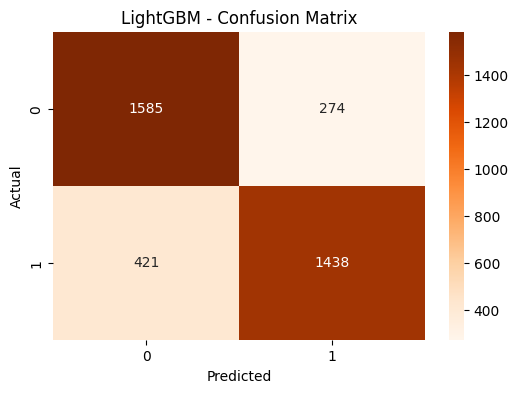

In [ ]:
# ==========================================
# LightGBM Classifier
# ==========================================

!pip install lightgbm --quiet
import lightgbm as lgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Train LightGBM Model (GPU Enabled)
lgb_model = lgb.LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    metric='binary_logloss',
    num_leaves=31,
    learning_rate=0.05,
    n_estimators=200,
    device='gpu',   # comment this line if GPU not available
    random_state=42
)

lgb_model.fit(X_train, y_train)

# Predictions
y_pred_lgb = lgb_model.predict(X_test)

# Evaluation
print("✅ LightGBM Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lgb) * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lgb))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_lgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('LightGBM - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
plt.savefig("Fig_X_ModelName.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

/tmp/ipython-input-1252903218.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Score', data=metrics_df_lgb, palette='Oranges_d')


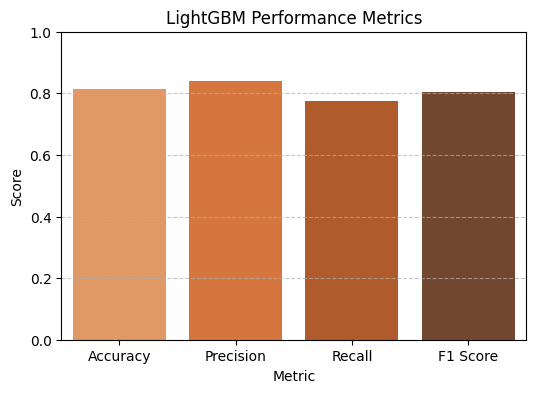

In [ ]:
# ==========================================
# 📊 LightGBM Performance Metrics Visualization
# ==========================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

metrics_lgb = {
    'Accuracy': accuracy_score(y_test, y_pred_lgb),
    'Precision': precision_score(y_test, y_pred_lgb),
    'Recall': recall_score(y_test, y_pred_lgb),
    'F1 Score': f1_score(y_test, y_pred_lgb)
}

metrics_df_lgb = pd.DataFrame(list(metrics_lgb.items()), columns=['Metric', 'Score'])

plt.figure(figsize=(6, 4))
sns.barplot(x='Metric', y='Score', data=metrics_df_lgb, palette='Oranges_d')
plt.title('LightGBM Performance Metrics')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



In [ ]:
plt.savefig("Fig_X_ModelName.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

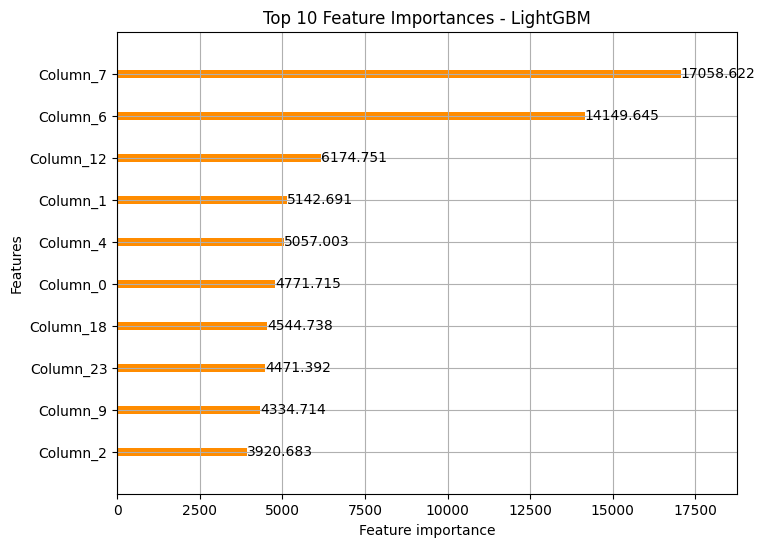

In [ ]:
lgb.plot_importance(lgb_model, max_num_features=10, importance_type='gain', figsize=(8,6), color='darkorange')
plt.title('Top 10 Feature Importances - LightGBM')
plt.show()


In [ ]:
plt.savefig("Fig_X_ModelName.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [ ]:
# ==========================================
# 🔍 Grid Search Optimization - LightGBM
# ==========================================
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb

param_grid = {
    'num_leaves': [15, 31, 63],
    'max_depth': [-1, 5, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'boosting_type': ['gbdt', 'dart']
}

grid_lgb = GridSearchCV(
    estimator=lgb.LGBMClassifier(objective='binary', random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

print("🚀 Running Grid Search for LightGBM...")
grid_lgb.fit(X_train, y_train)

print("\n✅ Best Parameters:", grid_lgb.best_params_)
print("✅ Best Cross-Validation Accuracy:", round(grid_lgb.best_score_ * 100, 2), "%")

# Evaluate best model on test set
best_lgb = grid_lgb.best_estimator_
y_pred_gs_lgb = best_lgb.predict(X_test)
print("\nTest Accuracy:", round(accuracy_score(y_test, y_pred_gs_lgb) * 100, 2), "%")


🚀 Running Grid Search for LightGBM...
Fitting 3 folds for each of 162 candidates, totalling 486 fits
[LightGBM] [Info] Number of positive: 7434, number of negative: 7434
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001195 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3667
[LightGBM] [Info] Number of data points in the train set: 14868, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

✅ Best Parameters: {'boosting_type': 'gbdt', 'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 300, 'num_leaves': 63}
✅ Best Cross-Validation Accuracy: 81.98 %

Test Accuracy: 83.22 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# ==========================================
# 📊 Classification Report for Best LightGBM Model
# ==========================================
from sklearn.metrics import classification_report, confusion_matrix

print("📄 Classification Report for Best LightGBM Model:\n")
print(classification_report(y_test, y_pred_gs_lgb))

# Optional: Confusion Matrix
print("\n🔢 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gs_lgb))


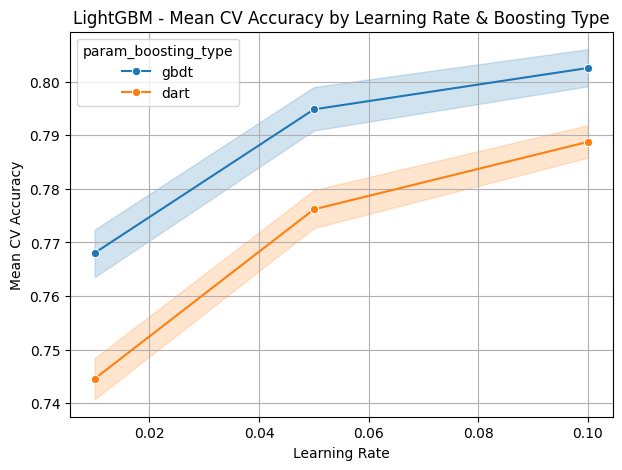

In [ ]:
# ==========================================
# 📊 Visualization — Mean Accuracy vs Learning Rate
# ==========================================
results = pd.DataFrame(grid_lgb.cv_results_)
plt.figure(figsize=(7, 5))
sns.lineplot(
    data=results,
    x='param_learning_rate',
    y='mean_test_score',
    hue='param_boosting_type',
    marker='o'
)
plt.title("LightGBM - Mean CV Accuracy by Learning Rate & Boosting Type")
plt.xlabel("Learning Rate")
plt.ylabel("Mean CV Accuracy")
plt.grid(True)
plt.show()

the new improved

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.5 MB/s eta 0:00:00
✅ Libraries imported successfully


Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv
📁 Dataset Loaded: (30000, 25)
After removing invalid rows & duplicates: (29965, 24)
✅ Missing values handled
⚠️ Outliers removed too many minority samples → Skipping IQR filtering
After outlier handling: (29965, 24)
✅ Target Encoding applied
Train/Test Split Complete
Before balancing:
 default
0    18668
1     5304
Name: count, dtype: int64
After balancing:
 default
0    6288
1    6288
Name: count, dtype: int64
Selected Features:
Index(['LIMIT_BAL', 'MARRIAGE', 'PAY_0', 'PAY_2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT5'],
      dtype='object')
[LightGBM] [Info] Number of positive: 6288, number of negative: 6288
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2559
[LightGBM] [Info] Number of data points in the train set: 12576, number of used features: 12
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 6288, number of negative: 6288
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2559
[LightGBM] [Info] Number of data points in the train set: 12576, number of used features: 12
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 12 dense feature groups (0.14 MB) transferred to GPU in 0.000700 secs. 0 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


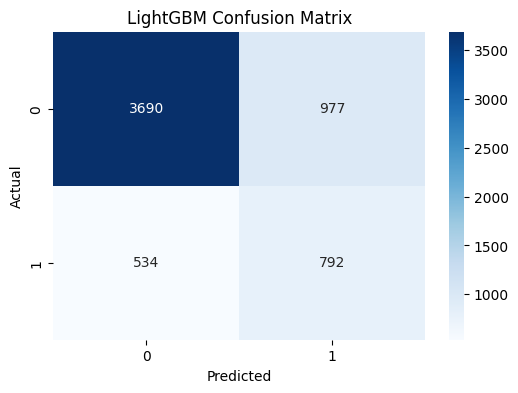

In [ ]:
# ============================================================
# 0️⃣ INSTALL REQUIRED LIBRARIES
# ============================================================
!pip install lightgbm imbalanced-learn category_encoders --quiet

# ============================================================
# 1️⃣ IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Feature Selection
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Encoding
from category_encoders import TargetEncoder

# Balancing
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

import lightgbm as lgb
from google.colab import files

print("✅ Libraries imported successfully")

# ============================================================
# 2️⃣ UPLOAD DATASET MANUALLY
# ============================================================
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])
print(f"📁 Dataset Loaded: {df.shape}")

# Standardize target column name
if "default.payment.next.month" in df.columns:
    df.rename(columns={"default.payment.next.month": "default"}, inplace=True)

# Drop ID column if present
if "ID" in df.columns:
    df.drop(columns=["ID"], inplace=True)

# ============================================================
# 3️⃣ REMOVE INVALID OR IRRELEVANT RECORDS
# ============================================================
df = df[df["default"].isin([0,1])]    # Keep only valid class values
df.drop_duplicates(inplace=True)

print(f"After removing invalid rows & duplicates: {df.shape}")

# ============================================================
# 4️⃣ HANDLE MISSING VALUES
# ============================================================
# Numeric → median | Categorical → mode
for col in df.columns:
    if df[col].dtype in ["float64","int64"]:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("✅ Missing values handled")

# ============================================================
# 5️⃣ OUTLIER REMOVAL (IQR)
# ============================================================
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

filtered_df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

# ensure minority class not erased
if filtered_df["default"].nunique() == 2:
    df = filtered_df
else:
    print("⚠️ Outliers removed too many minority samples → Skipping IQR filtering")

print(f"After outlier handling: {df.shape}")

# ============================================================
# 6️⃣ FEATURE ENCODING
# ============================================================
# Identify categorical columns
cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]

# Target Encoding
encoder = TargetEncoder(cols=cat_cols)
df[cat_cols] = encoder.fit_transform(df[cat_cols], df["default"])

print("✅ Target Encoding applied")

# ============================================================
# 7️⃣ TRAIN–TEST SPLIT
# ============================================================
X = df.drop("default", axis=1)
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train/Test Split Complete")

# ============================================================
# 8️⃣ CLASS IMBALANCE HANDLING
# ============================================================
print("Before balancing:\n", y_train.value_counts())

# Step 1 — Random Undersampling (reduce majority class slightly)
rus = RandomUnderSampler(sampling_strategy=0.75, random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Step 2 — SMOTE + Tomek Links for refined balancing
smt = SMOTETomek(random_state=42)
X_train_bal, y_train_bal = smt.fit_resample(X_train_rus, y_train_rus)

print("After balancing:\n", y_train_bal.value_counts())

# ============================================================
# 9️⃣ NORMALIZATION
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# 🔟 FEATURE SELECTION (FILTER → WRAPPER)
# ============================================================
# Filter Method — Mutual Information
filter_selector = SelectKBest(mutual_info_classif, k=20)
X_train_f = filter_selector.fit_transform(X_train_scaled, y_train_bal)
X_test_f = filter_selector.transform(X_test_scaled)

filter_features = X.columns[filter_selector.get_support()]

# Wrapper Method — RFE with Logistic Regression
rfe = RFE(LogisticRegression(max_iter=2000), n_features_to_select=12)
X_train_final = rfe.fit_transform(X_train_f, y_train_bal)
X_test_final = rfe.transform(X_test_f)

final_features = filter_features[rfe.support_]

print("Selected Features:")
print(final_features)

# ============================================================
# 1️⃣1️⃣ LIGHTGBM MODEL
# ============================================================
lgbm = lgb.LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    device='gpu',     # GPU ENABLED
    n_estimators=200,
    random_state=42
)

lgbm.fit(X_train_final, y_train_bal)
y_pred = lgbm.predict(X_test_final)

print("Initial LightGBM Accuracy:", accuracy_score(y_test, y_pred))

# ============================================================
# 1️⃣2️⃣ GRID SEARCH OPTIMIZATION
# ============================================================
param_grid = {
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 5, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200, 300]
}

grid = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_final, y_train_bal)

print("\nBest Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

# Final evaluation
best_model = grid.best_estimator_
final_pred = best_model.predict(X_test_final)

print("\nFinal Test Accuracy:", accuracy_score(y_test, final_pred))
print(classification_report(y_test, final_pred, zero_division=0))

# ============================================================
# 1️⃣3️⃣ VISUALIZATION — CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_test, final_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
